In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import math
import csv
import os.path

"""
Parameters to change (possibly)
"""
PARTICLES = 1000
N = 6 # number of states

HEIGHT_THRESHOLD = 0.0  # meters
GROUND_HEIGHT_THRESHOLD = -.4  # meters
DT = 0.1 # timestep (10Hz)
X_LANDMARK = 5.  # meters
Y_LANDMARK = -5.  # meters
EARTH_RADIUS = 6.3781E6  # meters


def load_data(filename):
    """Load data from the csv log

    Parameters:
    filename (str)  -- the name of the csv log

    Returns:
    data (dict)     -- the logged data with data categories as keys
                       and values list of floats
    """
    is_filtered = False
    if os.path.isfile(filename + "_filtered.csv"):
        f = open(filename + "_filtered.csv")
        is_filtered = True
    else:
        f = open(filename + ".csv")

    file_reader = csv.reader(f, delimiter=',')

    # Load data into dictionary with headers as keys
    data = {}
    header = ["X", "Y", "Z", "Time Stamp", "Latitude", "Longitude",
              "Yaw", "Pitch", "Roll", "AccelX", "AccelY", "AccelZ"]
    for h in header:
        data[h] = []

    row_num = 0
    f_log = open("bad_data_log.txt", "w")
    for row in file_reader:
        for h, element in zip(header, row):
            # If got a bad value just use the previous value
            try:
                data[h].append(float(element))
            except ValueError:
                data[h].append(data[h][-1])
                f_log.write(str(row_num) + "\n")

        row_num += 1
    f.close()
    f_log.close()

    return data, is_filtered


def save_data(data, filename):
    """Save data from dictionary to csv

    Parameters:
    filename (str)  -- the name of the csv log
    data (dict)     -- data to log
    """
    header = ["X", "Y", "Z", "Time Stamp", "Latitude", "Longitude",
              "Yaw", "Pitch", "Roll", "AccelX", "AccelY", "AccelZ"]
    f = open(filename, "w")
    num_rows = len(data["X"])
    for i in range(num_rows):
        for h in header:
            f.write(str(data[h][i]) + ",")

        f.write("\n")

    f.close()


def filter_data(data):
    """Filter lidar points based on height and duplicate time stamp

    Parameters:
    data (dict)             -- unfilterd data

    Returns:
    filtered_data (dict)    -- filtered data
    """

    # Remove data that is not above a height threshold to remove
    # ground measurements and remove data below a certain height
    # to remove outliers like random birds in the Linde Field (fuck you birds)
    filter_idx = [idx for idx, ele in enumerate(data["Z"])
                  if ele > GROUND_HEIGHT_THRESHOLD and ele < HEIGHT_THRESHOLD]

    filtered_data = {}
    for key in data.keys():
        filtered_data[key] = [data[key][i] for i in filter_idx]

    # Remove data that at the same time stamp
    ts = filtered_data["Time Stamp"]
    filter_idx = [idx for idx in range(1, len(ts)) if ts[idx] != ts[idx-1]]
    for key in data.keys():
        filtered_data[key] = [filtered_data[key][i] for i in filter_idx]

    return filtered_data


def convert_gps_to_xy(lat_gps, lon_gps, lat_origin, lon_origin):
    """Convert gps coordinates to cartesian with equirectangular projection

    Parameters:
    lat_gps     (float)    -- latitude coordinate
    lon_gps     (float)    -- longitude coordinate
    lat_origin  (float)    -- latitude coordinate of your chosen origin
    lon_origin  (float)    -- longitude coordinate of your chosen origin

    Returns:
    x_gps (float)          -- the converted x coordinate
    y_gps (float)          -- the converted y coordinate
    """
    x_gps = EARTH_RADIUS*(math.pi/180.)*(lon_gps - lon_origin)*math.cos((math.pi/180.)*lat_origin)
    y_gps = EARTH_RADIUS*(math.pi/180.)*(lat_gps - lat_origin)

    return x_gps, y_gps


def wrap_to_pi(angle):
    """Wrap angle data in radians to [-pi, pi]

    Parameters:
    angle (float)   -- unwrapped angle

    Returns:
    angle (float)   -- wrapped angle
    """
    while angle >= math.pi:
        angle -= 2*math.pi

    while angle <= -math.pi:
        angle += 2*math.pi
    return angle

In [3]:
import numpy as np
#from utils import *
def propagate_state(x_t_prev, u_t_noiseless):
    """Velocity-based motion with heavy damping"""

    # Extract states
    x = x_t_prev[0]
    y = x_t_prev[1]
    theta = x_t_prev[2]
    vx = x_t_prev[3]
    vy = x_t_prev[4]

    # Extract control
    accel_x_robot = u_t_noiseless[0]
    accel_y_robot = u_t_noiseless[1]

    # Transform to global frame
    ax_global = accel_x_robot * np.cos(theta) - accel_y_robot * np.sin(theta)
    ay_global = accel_x_robot * np.sin(theta) + accel_y_robot * np.cos(theta)

    # Update velocity with HEAVY damping
    damping = 0.75  # Lose 20% of velocity each timestep
    vx_new = damping * vx + ax_global * DT
    vy_new = damping * vy + ay_global * DT

    # Cap velocity
    MAX_VEL = 1.2  # m/s
    speed = np.sqrt(vx_new**2 + vy_new**2)
    if speed > MAX_VEL:
        scale = MAX_VEL / speed
        vx_new *= scale
        vy_new *= scale

    # Update position
    x_new = x + vx_new * DT
    y_new = y + vy_new * DT

    # Update heading from velocity direction (if moving)
    if speed > 0.1:
        theta_new = np.arctan2(vy_new, vx_new)
    else:
        theta_new = theta

    x_bar_t = np.array([x_new, y_new, theta_new, vx_new, vy_new, 0.0])

    return x_bar_t

def prediction_and_correction_step(x_t_prev, u_t, z_t):
    """Compute the prediction and correction (re-weighting) for the PF

    Parameters:
    x_t_prev (np.array)         -- the previous state estimate
    u_t (np.array)              -- the control input
    z_t (np.array)              -- the current measurement

    Returns:
    x_bar_t (np.array)          -- the predicted state estimate of time t
    """


    num_particles = x_t_prev.shape[1]
    x_bar_t = np.zeros_like(x_t_prev)

    # Motion noise standard deviations (tune these!)
    std_x = 0.05        # position noise (m)
    std_y = 0.05
    std_theta = 0.05    # angle noise (rad)
    std_vx = 0.25        # velocity noise (m/s)
    std_vy = 0.25

    # Measurement noise standard deviations (tune these!)
    std_z_x = 0.025       # measurement position noise (m)
    std_z_y = 0.025
    std_z_theta = 0.06   # measurement angle noise (rad)


    # =========================================================================
    # PREDICTION STEP - Propagate each particle
    # =========================================================================
    for i in range(num_particles):
        # Get this particle's state
        x_particle = x_t_prev[:, i]

        # Add noise to control input (process noise)
        u_noisy = u_t.copy()
        u_noisy[0] += np.random.randn() * std_vx  # noisy acceleration
        u_noisy[1] += np.random.randn() * std_vy

        # Propagate using clean motion model
        x_bar_particle = propagate_state(x_particle, u_noisy)

        # Add process noise to state
        x_bar_particle[0] += np.random.randn() * std_x  # position noise
        x_bar_particle[1] += np.random.randn() * std_y
        x_bar_particle[2] += np.random.randn() * std_theta  # angle noise
        x_bar_particle[2] = wrap_to_pi(x_bar_particle[2])

        # Store predicted particle
        x_bar_t[:, i] = x_bar_particle

    # =========================================================================
    # CORRECTION STEP - Compute weights based on measurement likelihood
    # =========================================================================
    weights = np.zeros(num_particles)

    for i in range(num_particles):
        # Predicted measurement (what would we measure if robot was here?)
        pred_x = x_bar_t[0, i]
        pred_y = x_bar_t[1, i]
        pred_theta = x_bar_t[2, i]

        # Measurement residuals (innovation)
        diff_x = z_t[0] - pred_x
        diff_y = z_t[1] - pred_y
        diff_theta = wrap_to_pi(z_t[2] - pred_theta)

        # Compute likelihood using Gaussian probability density function
        # p(z|x) = exp(-0.5 * (z-h(x))^2 / sigma^2) / (sigma * sqrt(2*pi))
        prob_x = np.exp(-0.5 * (diff_x / std_z_x)**2) / (std_z_x * np.sqrt(2 * np.pi))
        prob_y = np.exp(-0.5 * (diff_y / std_z_y)**2) / (std_z_y * np.sqrt(2 * np.pi))
        prob_theta = np.exp(-0.5 * (diff_theta / std_z_theta)**2) / (std_z_theta * np.sqrt(2 * np.pi))

        # Combined likelihood (assume measurements are independent)
        weights[i] = prob_x * prob_y * prob_theta

    # Normalize weights to sum to 1
    weights += 1e-300  # Avoid division by zero
    weights /= np.sum(weights)

    # Store weights in state array (use last row)
    x_bar_t[5, :] = weights

    return x_bar_t

In [4]:
import numpy as np
#from utils import *

def resample_step(x_bar_t):
    """Ressampling step for the PF

    Parameters:
    x_bar_t       (np.array)    -- the predicted state estimate of time t
    """
    num_particles = x_bar_t.shape[1]
    weights = x_bar_t[5,:] # extract weights (stored in row 5 from prediction step)

    #resample particles based on weights
    #use systematic resampling
    indices = systematic_resample(weights)

    #create new particle set
    x_est_t = x_bar_t[:,indices]

    #reset weights to uniform (since all particles now equally likely)
    x_est_t[5,:] = 1.0 / num_particles
    #x_est_t = x_bar_t

    return x_est_t


def systematic_resample(weights):
    """Systematic resampling algorithm

    Parameters:
    weights (np.array)  -- particle weights (num_particles,)

    Returns:
    indices (np.array)  -- resampled particle indices
    """
    num_particles = len(weights)

    # Cumulative sum of weights
    cumsum = np.cumsum(weights)
    cumsum[-1] = 1.0  # Avoid numerical issues

    # Start at random position
    positions = (np.arange(num_particles) + np.random.random()) / num_particles

    indices = np.zeros(num_particles, dtype=int)
    i, j = 0, 0

    while i < num_particles:
        if positions[i] < cumsum[j]:
            indices[i] = j
            i += 1
        else:
            j += 1

    return indices


 kidnapped robot at t = 35 (3.5s)! Scattering particles ...


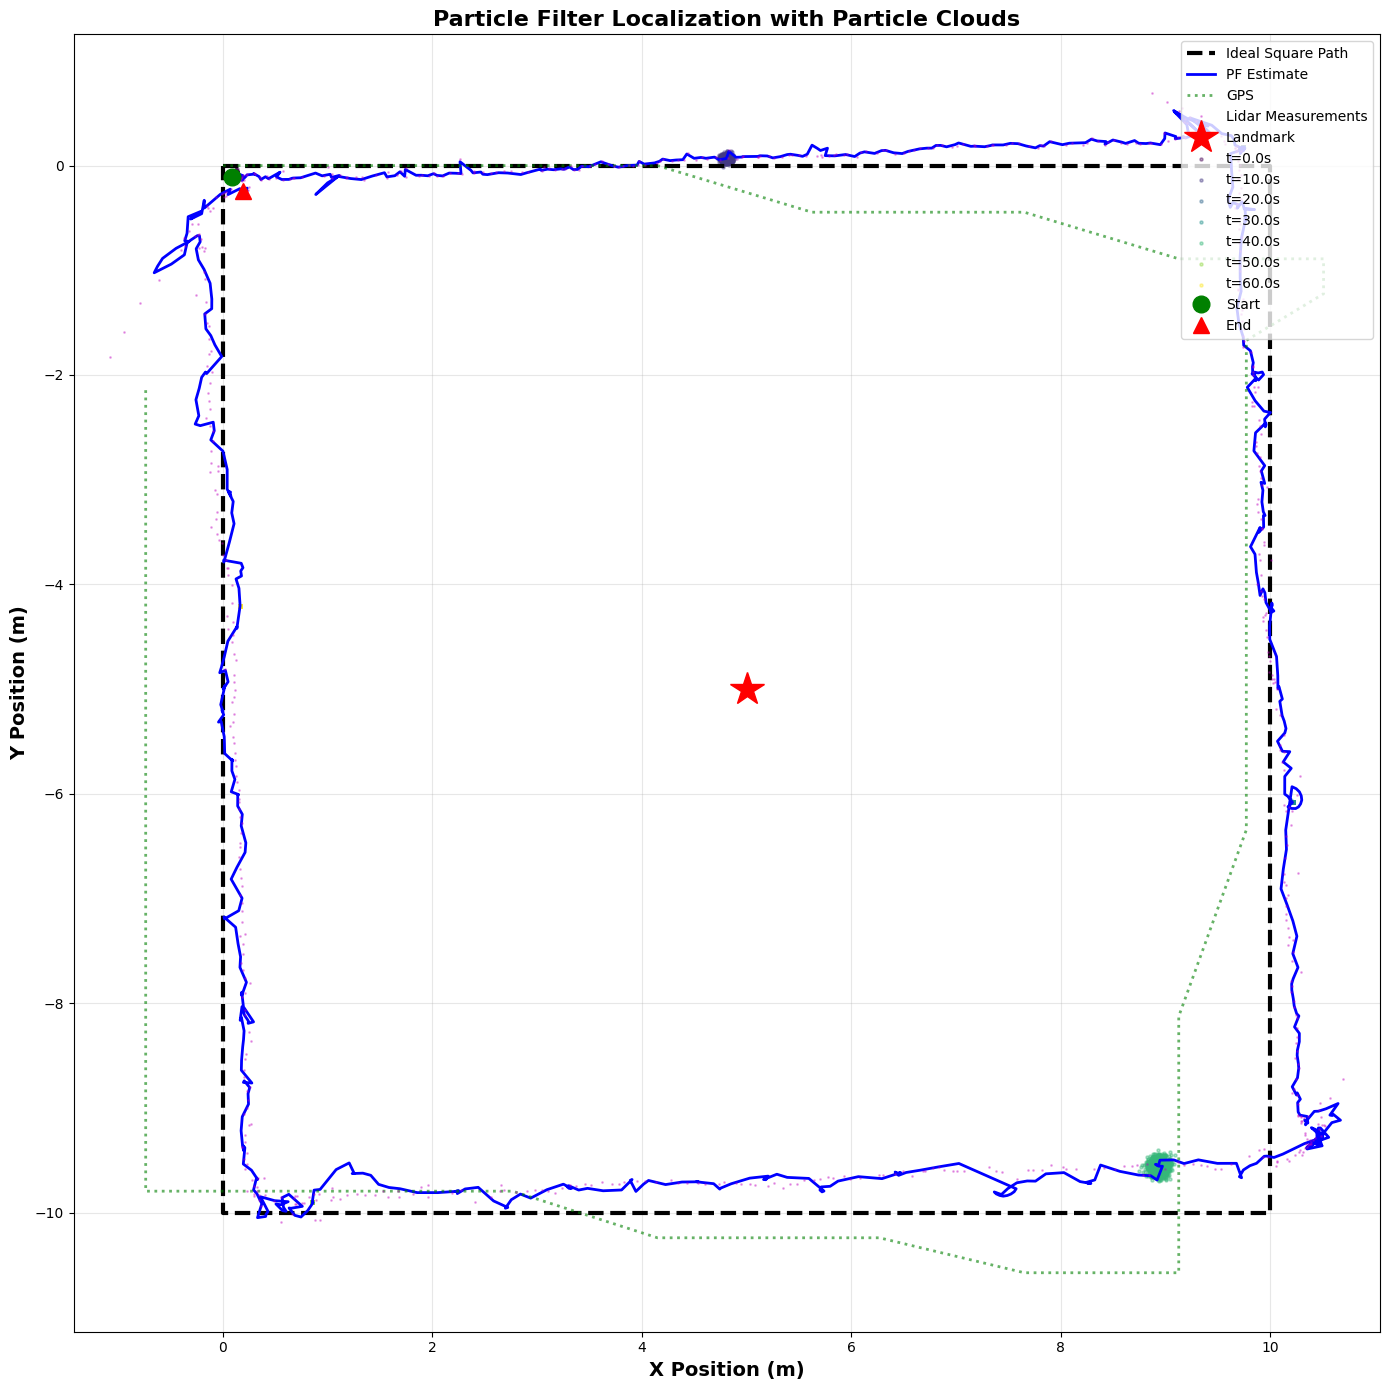

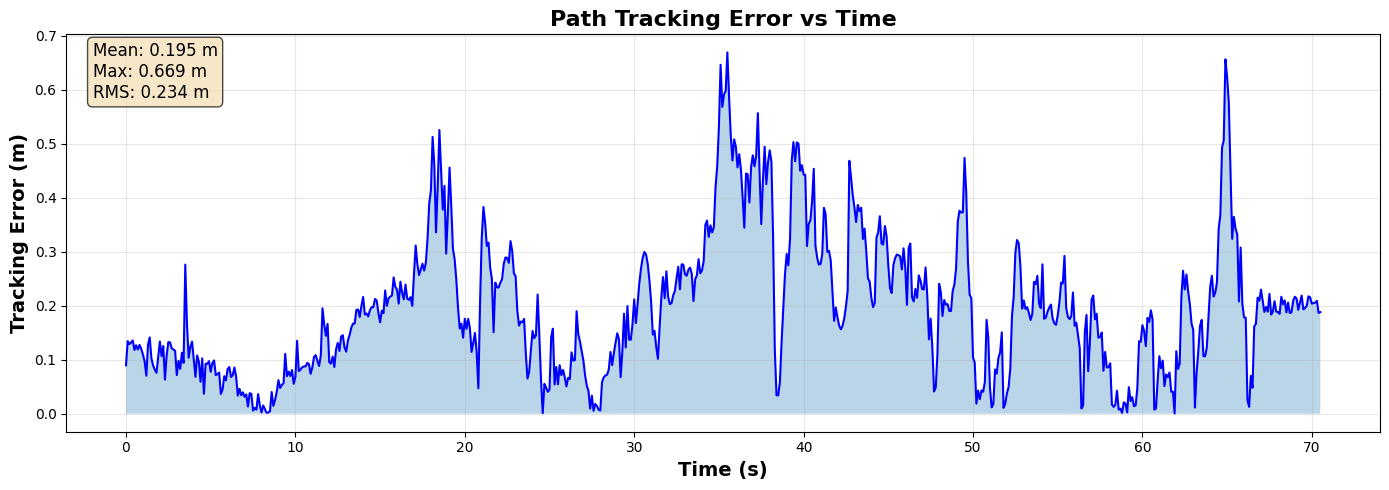


PARTICLE FILTER RESULTS
Mean tracking error:  0.195 m
Max tracking error:   0.669 m
RMS tracking error:   0.234 m


In [5]:
"""
Author: Andrew Q. Pham, Victor Shia, Viviane Solomon
Email: apham@g.hmc.edu, vshia@g.hmc.edu, vsolomon@g.hmc.edu
Date of Creation: 2/26/20
Description:
    Particle filter implementation to filtering localization estimate
    This code is for teaching purposes for HMC ENGR205 System Simulation Lab 4
    Student code version with parts omitted.
"""


import matplotlib.pyplot as plt
import numpy as np
#import shelve
#from utils import *
#from prediction import prediction_and_correction_step
#from resample import resample_step


def moving_average(x, window = 10):
    return np.convolve(x, 1.0 * np.ones(window) / window, 'full')


def main():
    """Run a PF on logged data from IMU and LiDAR moving in a box formation around a landmark"""

    #filename="./shelve.out"
    #my_shelf = shelve.open(filename, "n") # 'n' for new

    filepath = "/content/drive/MyDrive/"
    filename = "E205/E205LABS/E205Lab3/2020_2_26__17_21_59_filtered"
    data, is_filtered = load_data(filepath + filename)

    # Save filtered data so don't have to process unfiltered data everytime
    if not is_filtered:
        data = filter_data(data)
        save_data(data, filepath+filename+"_filtered.csv")

    # Load data into variables
    x_lidar = data["X"]
    y_lidar = data["Y"]
    z_lidar = data["Z"]
    time_stamps = data["Time Stamp"]
    lat_gps = data["Latitude"]
    lon_gps = data["Longitude"]
    yaw_lidar = data["Yaw"]
    pitch_lidar = data["Pitch"]
    roll_lidar = data["Roll"]
    x_ddot = data["AccelX"]
    y_ddot = data["AccelY"]

    x_ddot = moving_average(x_ddot)
    y_ddot = moving_average(y_ddot)

    lat_origin = lat_gps[0]
    lon_origin = lon_gps[0]

    #  Initialize filter
    """STUDENT CODE START"""
    # Number of particles
    num_particles = PARTICLES  # 200

    # Initialize state estimates (all particles for all timesteps)
    # Shape: (num_states, num_particles, num_timesteps)
    state_estimates = np.zeros((N, num_particles, len(time_stamps)))

    # Initialize particles
    # Option A: Known start (all particles at origin)
    state_est_t_prev = np.zeros((N, num_particles))
    state_est_t_prev[0, :] = 0.0  # x = 0
    state_est_t_prev[1, :] = 0.0  # y = 0
    state_est_t_prev[2, :] = 0.0  # theta = 0

    # Option B: Unknown start (particles scattered randomly)
    # Uncomment this for the "unknown start" comparison
    #state_est_t_prev = np.zeros((N, num_particles))
    #state_est_t_prev[0, :] = np.random.uniform(0, 10, num_particles)   # x scattered in [0, 10]
    #state_est_t_prev[1, :] = np.random.uniform(-10, 0, num_particles)  # y scattered in [-10, 0]
    #state_est_t_prev[2, :] = np.random.uniform(-np.pi, np.pi, num_particles)  # theta random

    # Initialize velocities to zero (states 3, 4, 5)
    state_est_t_prev[3:, :] = 0.0

    # Storage for GPS and lidar measurements (for plotting later)
    gps_estimates = np.zeros((2, len(time_stamps)))
    lidar_pos = np.zeros((2, len(time_stamps)))

    """STUDENT CODE END"""

    #  Run filter over data
    for t, _ in enumerate(time_stamps):
        # Get control input
        """STUDENT CODE START"""
        # Control input: u_t = [accel_x, accel_y, yaw_rate]
        u_t = np.array([x_ddot[t], y_ddot[t], 0.0])  # We'll compute yaw rate from yaw measurements

        # Measurement: z_t = [z_x, z_y, z_theta]
        # These are the transformed lidar measurements (same as Lab 3)

        # First, convert yaw from CW to CCW (Lab 3 reminder!)
        theta_imu = wrap_to_pi(-np.deg2rad(yaw_lidar[t]))  # Negate for CW->CCW, convert to radians

        # Apply Hint 5 transformation from Lab 3
        z_x = X_LANDMARK - (y_lidar[t] * np.cos(theta_imu) + x_lidar[t] * np.sin(theta_imu))
        z_y = Y_LANDMARK - (y_lidar[t] * np.sin(theta_imu) - x_lidar[t] * np.cos(theta_imu))
        z_theta = theta_imu

        z_t = np.array([z_x, z_y, z_theta])


        #### KIDNAPPED ROBOT PROBLEM

        if t == 35: #halfway through, at 35 seconds
         print(f"\n kidnapped robot at t = {t} ({t*DT:.1f}s)! Scattering particles ...")
          #scatter particles randomly across square
         state_est_t_prev[0, :] = np.random.uniform(0, 10, num_particles)
         state_est_t_prev[1, :] = np.random.uniform(-10, 0, num_particles)
         state_est_t_prev[2, :] = np.random.uniform(-np.pi, np.pi, num_particles)
         state_est_t_prev[3:, :] = 0.0 #reset velocities


        """STUDENT CODE END"""

        # Prediction Step
        state_pred_t = prediction_and_correction_step(state_est_t_prev, u_t, z_t)
        state_est_t = resample_step(state_pred_t)

        #  For clarity sake/teaching purposes, we explicitly update t->(t-1)
        state_est_t_prev = state_est_t

        # Log Data
        state_estimates[:, :, t] = state_est_t

        x_gps, y_gps = convert_gps_to_xy(lat_gps=lat_gps[t],
                                         lon_gps=lon_gps[t],
                                         lat_origin=lat_origin,
                                         lon_origin=lon_origin)
        gps_estimates[:, t] = np.array([x_gps, y_gps])
        lidar_pos[:,t] = np.array([z_x, z_y])

    #for key in dir():
    #    try:
    #        my_shelf[key] = eval(key)
    #    except Exception:
            #
            # __builtins__, my_shelf, and imported modules can not be shelved.
            #
    #        print('ERROR shelving: {0}'.format(key))
    #my_shelf.close()


    """STUDENT CODE START"""
    # Plot here

    # Compute mean estimate from particles at each timestep
    mean_estimates = np.zeros((3, len(time_stamps)))
    for t in range(len(time_stamps)):
        # Weighted mean of particles
        weights = state_estimates[5, :, t]
        mean_estimates[0, t] = np.average(state_estimates[0, :, t], weights=weights)
        mean_estimates[1, t] = np.average(state_estimates[1, :, t], weights=weights)

        # Circular mean for theta
        mean_estimates[2, t] = np.arctan2(
            np.average(np.sin(state_estimates[2, :, t]), weights=weights),
            np.average(np.cos(state_estimates[2, :, t]), weights=weights)
        )

    # =========================================================================
    # PLOT 1: Path with Particle Clouds
    # =========================================================================
    fig, ax = plt.subplots(figsize=(14, 14))

    # Ideal square path
    square_x = [0, 10, 10, 0, 0]
    square_y = [0, 0, -10, -10, 0]
    ax.plot(square_x, square_y, 'k--', linewidth=3, label='Ideal Square Path')

    # Estimated path (mean of particles)
    ax.plot(mean_estimates[0, :], mean_estimates[1, :], 'b-', linewidth=2, label='PF Estimate')

    # GPS track
    ax.plot(gps_estimates[0, :], gps_estimates[1, :], 'g:', linewidth=2, alpha=0.6, label='GPS')

    # Lidar measurements
    ax.plot(lidar_pos[0, :], lidar_pos[1, :], 'm.', markersize=2, alpha=0.3, label='Lidar Measurements')

    # Landmark
    ax.plot(X_LANDMARK, Y_LANDMARK, 'r*', markersize=25, label='Landmark', zorder=10)

    # Plot particle clouds at specific timesteps
    particle_timesteps = [0, 100, 200, 300, 400, 500, 600]
    colors = plt.cm.viridis(np.linspace(0, 1, len(particle_timesteps)))

    for idx, t in enumerate(particle_timesteps):
        if t < len(time_stamps):
            particles_x = state_estimates[0, :, t]
            particles_y = state_estimates[1, :, t]
            ax.scatter(particles_x, particles_y, s=5, alpha=0.4, color=colors[idx],
                      label=f't={t*DT:.1f}s')

    ax.plot(mean_estimates[0, 0], mean_estimates[1, 0], 'go', markersize=12, label='Start', zorder=10)
    ax.plot(mean_estimates[0, -1], mean_estimates[1, -1], 'r^', markersize=12, label='End', zorder=10)

    ax.set_xlabel('X Position (m)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontsize=14, fontweight='bold')
    ax.set_title('Particle Filter Localization with Particle Clouds', fontsize=16, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.savefig('pf_path_with_particles.png', dpi=300)
    plt.show()

    # =========================================================================
    # PLOT 2: Tracking Error
    # =========================================================================
    # Compute tracking error (distance from estimated path to ideal square)
    def compute_tracking_error(estimated_path, square_corners):
        """Compute minimum distance from each point to square edges"""
        errors = []
        for i in range(estimated_path.shape[1]):
            point = estimated_path[:2, i]
            min_dist = float('inf')

            # Check distance to each edge
            edges = [
                ([0, 0], [10, 0]),     # Bottom edge
                ([10, 0], [10, -10]),  # Right edge
                ([10, -10], [0, -10]), # Top edge
                ([0, -10], [0, 0])     # Left edge
            ]

            for p1, p2 in edges:
                p1 = np.array(p1)
                p2 = np.array(p2)

                # Distance from point to line segment
                v = p2 - p1
                w = point - p1
                c1 = np.dot(w, v)

                if c1 <= 0:
                    dist = np.linalg.norm(point - p1)
                else:
                    c2 = np.dot(v, v)
                    if c1 >= c2:
                        dist = np.linalg.norm(point - p2)
                    else:
                        b = c1 / c2
                        proj = p1 + b * v
                        dist = np.linalg.norm(point - proj)

                min_dist = min(min_dist, dist)

            errors.append(min_dist)

        return np.array(errors)

    errors = compute_tracking_error(mean_estimates, square_corners=None)

    plt.figure(figsize=(14, 5))
    plt.plot(np.arange(len(errors)) * DT, errors, 'b-', linewidth=1.5)
    plt.fill_between(np.arange(len(errors)) * DT, 0, errors, alpha=0.3)
    plt.xlabel('Time (s)', fontsize=14, fontweight='bold')
    plt.ylabel('Tracking Error (m)', fontsize=14, fontweight='bold')
    plt.title('Path Tracking Error vs Time', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add statistics
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    rms_error = np.sqrt(np.mean(errors**2))
    plt.text(0.02, 0.98, f'Mean: {mean_error:.3f} m\nMax: {max_error:.3f} m\nRMS: {rms_error:.3f} m',
            transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    plt.tight_layout()
    plt.savefig('pf_tracking_error.png', dpi=300)
    plt.show()

    print("\n" + "="*80)
    print("PARTICLE FILTER RESULTS")
    print("="*80)
    print(f"Mean tracking error:  {mean_error:.3f} m")
    print(f"Max tracking error:   {max_error:.3f} m")
    print(f"RMS tracking error:   {rms_error:.3f} m")
    print("="*80)




    """STUDENT CODE END"""
    return 0


if __name__ == "__main__":
    main()